# Energy Budget Scheduling — Algorithm Comparison
Paper: *Towards Energy Budget Control in HPC* — Dutot et al., CCGrid 2017

Compares six algorithms: **PC**, **energyBud**, **reducePC** × **IDLE** / **SHUTDOWN** variants
across five budget levels: **60 / 70 / 80 / 90 / 100 %** of peak cluster energy.

In [ ]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ALGORITHMS = [
    'pc_idle', 'energybud_idle', 'reducepc_idle',
    'pc_shutdown', 'energybud_shutdown', 'reducepc_shutdown',
]
LABELS = {
    'pc_idle':            'PC_IDLE',
    'energybud_idle':     'energyBud_IDLE',
    'reducepc_idle':      'reducePC_IDLE',
    'pc_shutdown':        'PC_SHUTDOWN',
    'energybud_shutdown': 'energyBud_SHUTDOWN',
    'reducepc_shutdown':  'reducePC_SHUTDOWN',
}
COLORS = {
    'pc_idle':            '#4C72B0',
    'energybud_idle':     '#DD8452',
    'reducepc_idle':      '#55A868',
    'pc_shutdown':        '#8FAADC',
    'energybud_shutdown': '#F0B27A',
    'reducepc_shutdown':  '#82C99A',
}

# Budget levels matching the paper (%)
BUDGETS = [100, 90, 80, 70, 60, 50, 49, 30]

TAU = 10.0  # AVEbsld bounding constant

# Budget window: middle 3 days of the 7-day trace
T_S = 172800  # day 2
T_E = 432000  # day 5

# Peak energy: 512 hosts all computing for the full 7-day week
PEAK_ENERGY_J = 512 * 190.74 * 604800  # 604800 s = 7 days

In [ ]:
def load_results():
    """Return dict: results[algo][budget_pct] = list of (jobs_df, schedule_df, energy_df)."""
    results = {}
    for algo in ALGORITHMS:
        results[algo] = {}
        for pct in BUDGETS:
            results[algo][pct] = []
            for jobs_path in sorted(glob.glob(f'out/{algo}/budget{pct}/*/jobs.csv')):
                sched_path  = jobs_path.replace('jobs.csv', 'schedule.csv')
                energy_path = jobs_path.replace('jobs.csv', 'consumed_energy.csv')
                if os.path.exists(sched_path) and os.path.exists(energy_path):
                    results[algo][pct].append((
                        pd.read_csv(jobs_path),
                        pd.read_csv(sched_path),
                        pd.read_csv(energy_path),
                    ))
    return results

def load_baseline():
    """Load unconstrained EASY baseline runs from out/easy/baseline/."""
    baseline = []
    for jobs_path in sorted(glob.glob('out/easy/baseline/*/jobs.csv')):
        sched_path  = jobs_path.replace('jobs.csv', 'schedule.csv')
        energy_path = jobs_path.replace('jobs.csv', 'consumed_energy.csv')
        if os.path.exists(sched_path) and os.path.exists(energy_path):
            baseline.append((
                pd.read_csv(jobs_path),
                pd.read_csv(sched_path),
                pd.read_csv(energy_path),
            ))
    return baseline

results  = load_results()
baseline = load_baseline()

for algo in ALGORITHMS:
    counts = [len(results[algo][pct]) for pct in BUDGETS]
    print(f"{LABELS[algo]}: {counts} runs at {BUDGETS}%")
print(f"easy baseline: {len(baseline)} run(s)")

In [33]:
T_WEEK = 604800  # 7 days in seconds

def total_energy_j(energy_df):
    """Total energy consumed during the full simulation (last cumulative value)."""
    return energy_df['energy'].iloc[-1]

def metrics_for_run(jobs, schedule, energy):
    # Jobs that started before the end of the week — paper ignores jobs
    # scheduled after the end of the week for time-period measures.
    ran_all  = jobs[jobs['starting_time'] >= 0]
    ran_week = ran_all[ran_all['starting_time'] < T_WEEK]
    N        = schedule['nb_computing_machines'].iloc[0]

    # Utilization: mean fraction of cluster compute-resources busy over the
    # full 7-day week. Job intervals are clipped to [0, T_WEEK].
    start       = ran_week['starting_time']
    end         = (start + ran_week['execution_time']).clip(upper=T_WEEK)
    busy_time   = (end - start).clip(lower=0)
    utilization = (
        (ran_week['requested_number_of_resources'] * busy_time).sum()
        / (N * T_WEEK)
    ) if N > 0 else float('nan')

    # AVEbsld: over all jobs of the trace (paper counts all of them).
    if ran_all.empty:
        avebsld = float('nan')
    else:
        wait    = ran_all['waiting_time']
        exe     = ran_all['execution_time']
        avebsld = ((wait + exe) / exe.clip(lower=TAU)).clip(lower=1.0).mean()

    return dict(utilization=utilization, avebsld=avebsld,
                energy_j=total_energy_j(energy))

# Build summary: one row per (algo, budget_pct), averaged across workloads
rows = []
for algo in ALGORITHMS:
    for pct in BUDGETS:
        run_metrics = [metrics_for_run(j, s, e) for j, s, e in results[algo][pct]]
        if not run_metrics:
            continue
        agg = pd.DataFrame(run_metrics).mean()
        agg['algo']       = algo
        agg['budget_pct'] = pct
        rows.append(agg)

summary = pd.DataFrame(rows)
summary['energy_ratio'] = summary['energy_j'] / PEAK_ENERGY_J

# Baseline: unconstrained EASY backfilling utilization over the whole week.
baseline_metrics  = [metrics_for_run(j, s, e) for j, s, e in baseline]
baseline_util_raw = pd.DataFrame(baseline_metrics)['utilization'].mean()
print(f"Unconstrained EASY baseline utilization (whole week): {baseline_util_raw:.3f}")

summary[['algo', 'budget_pct', 'utilization', 'energy_ratio', 'avebsld']]

Unconstrained EASY baseline utilization (whole week): 0.862


,algo,budget_pct,utilization,energy_ratio,avebsld
0,pc_idle,100,0.654338,0.898074,414.273437
1,pc_idle,90,0.588003,0.945559,504.604348
2,pc_idle,80,0.551204,0.957528,618.620325
3,pc_idle,70,0.520665,0.980946,686.387845
4,pc_idle,60,0.511782,0.987898,728.912469
5,pc_idle,50,0.510153,0.995098,739.888849
6,pc_idle,49,0.510153,0.995098,739.888849
7,pc_idle,30,0.510153,0.995098,739.888849
8,energybud_idle,100,0.783996,0.842573,239.782840
9,energybud_idle,90,0.740060,0.872454,297.289530


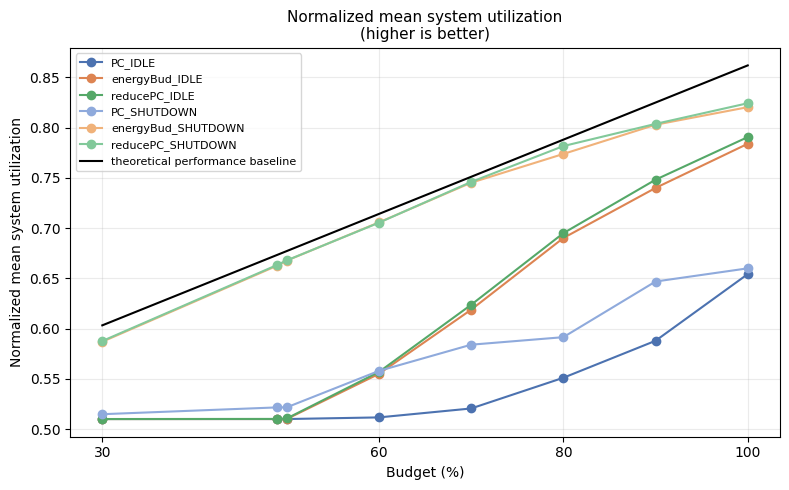

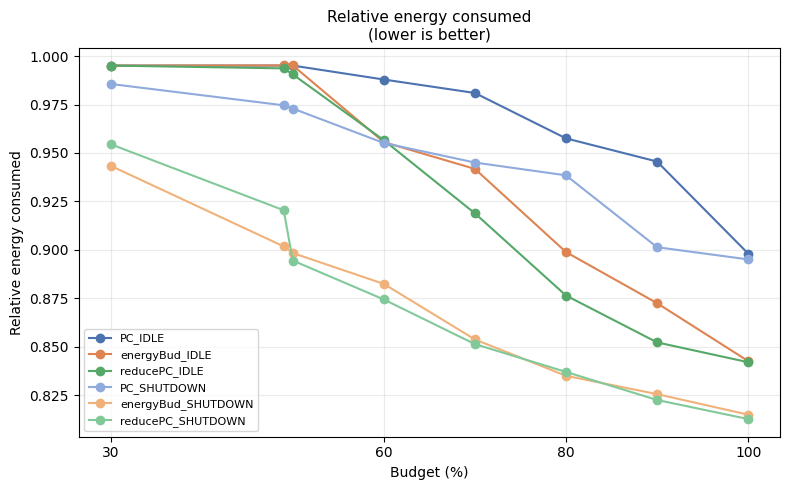

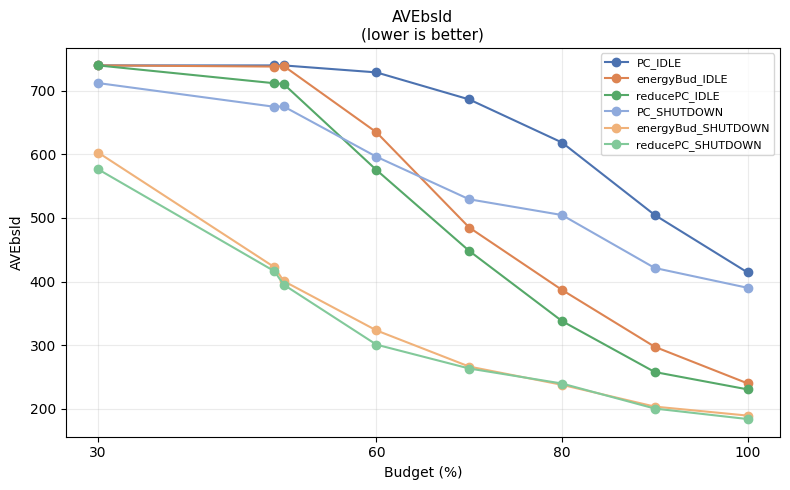

In [34]:
PLOT_BUDGETS = [30, 60, 80, 100]  # x-axis tick labels only

data = summary.copy()
data['budget_pct'] = data['budget_pct'].astype(int)
data = data.sort_values('budget_pct')

plots = [
    ('utilization',  'Normalized mean system utilization', 'higher is better', 'utilization.png'),
    ('energy_ratio', 'Relative energy consumed',           'lower is better',  'energy.png'),
    ('avebsld',      'AVEbsld',                            'lower is better',  'avebsld.png'),
]

for col, ylabel, note, filename in plots:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f'{ylabel}\n({note})', fontsize=11)

    for algo in ALGORITHMS:
        df = data[data['algo'] == algo]
        ax.plot(df['budget_pct'], df[col], marker='o',
                color=COLORS[algo], label=LABELS[algo])

    if col == 'utilization':
        # Theoretical performance baseline (paper Fig. 2):
        #   f(b) = u_EASY_bf * (3/7 * b + 4/7)
        # The factor 3/7 reflects that the energy budget is enforced only
        # during the 3-day window in the middle of the 7-day trace; the
        # other 4/7 of the week runs unconstrained.
        bvals = np.array(sorted(set(BUDGETS)), dtype=float)
        theor = baseline_util_raw * ((3.0 / 7.0) * (bvals / 100.0) + (4.0 / 7.0))
        ax.plot(bvals, theor, color='black', linewidth=1.5,
                label='theoretical performance baseline')

    ax.set_xlabel('Budget (%)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(PLOT_BUDGETS)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'out/{filename}', dpi=150, bbox_inches='tight')
    plt.show()